# RIFT-EEG Analysis Pipeline

**Author:** Christos Dalamarinis  
**Date:** March 2026    
**Status:** In developement

---

## Overview

This notebook implements the full RIFT-EEG analysis pipeline.
RIFT (Rapid Invisible Frequency Tagging) is a technique in which visual stimuli are
flickered at **60 Hz** — perceptually invisible, yet the brain entrains to the flicker,
producing a steady-state response detectable in the EEG.

**Core question:** Does the EEG signal show reliable phase-locking to the 60 Hz flicker?  
This is assessed via coherence between each EEG channel and a reference signal at the tagging frequency.

**Pipeline:**
1. Phase 1 — Data Loading and Initial Inspection
2. Phase 2 — Preprocessing
3. Phase 3 — Epoching and Epoch-Level Quality Control
4. Phase 4 — RIFT Coherence Analysis
5. Phase 5 — Statistical Testing
6. Phase 6 — Documentation, Reproducibility, and Export

---

## Libraries

| Library | Role |
|---|---|
| `mne` | Loading, preprocessing, epoching, spectral analysis |
| `numpy` / `scipy` | FFT, cross-spectral density, coherence, signal processing |
| `pandas` | Behavioral data, event logs, tabular summaries |
| `matplotlib` / `seaborn` | Visualization (spectra, topographies, coherence maps) |
| `autoreject` | Automated epoch rejection and repair |
| `mne-icalabel` | Automated IC classification (eye blinks, muscle, etc.) |
| `mne-connectivity` | Spectral connectivity (coherence) between EEG and reference signal |
| `statsmodels` / `pingouin` | Statistical testing, permutation tests |

---

# Phase 1 — Data Loading and Initial Inspection

Before any preprocessing, we load the raw `.bdf` recordings and verify that the data are intact and as expected.

**Steps:**
1. Load the raw data
2. Inspect the recording metadata (sampling rate, channels, duration, events)
3. Set channel types and attach the electrode montage
4. Visual inspection of the raw signal
5. Power Spectral Density (PSD) check — confirm the 60 Hz tagging peak is present

---
## Setup: Imports and Configuration

In [20]:
import os
import glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level('warning')
%matplotlib inline

print(f'MNE version   : {mne.__version__}')
print(f'NumPy version : {np.__version__}')

MNE version   : 1.11.0
NumPy version : 2.2.6


In [21]:
# -- Configuration ------------------------------------------------------------
# Set DATA_DIR to the "data" folder that contains the sub* subfolders.

# DATA_DIR = r'your/path/to/your/data'               #! change if data live elsewhere other than current working directory
DATA_DIR       = os.path.join(os.getcwd(), 'data')   #! change if data live elsewhere other than current working directory
EXPECTED_SFREQ = 1024                                # expected sampling rate (Hz)
TAGGING_FREQ   = 60.0                                # RIFT flicker frequency (Hz)

# Channel type assignments -- BioSemi ActiveTwo layout
MASTOID_CHANNELS = ['EXG5', 'EXG6']
EOG_CHANNELS     = ['EXG1', 'EXG2', 'EXG3', 'EXG4']
UNUSED_CHANNELS  = ['EXG7', 'EXG8']

# -- Auto-detect subjects from data/subX/ subfolders --------------------------
# Expected structure:
#   data/
#     sub1/
#       sub_1.bdf
#       output_s1.mat
#       awareness_s1.mat
#     sub2/
#       ...

bdf_files = sorted(glob.glob(os.path.join(DATA_DIR, 'sub*', '*.bdf')))          #! change if .bdf files are named differently

if not bdf_files:
    raise FileNotFoundError(f'No .bdf files found under: {DATA_DIR}/sub*/')

subjects = [
    {'subject_id': f'sub-{i+1:02d}', 'bdf_path': f}
    for i, f in enumerate(bdf_files)
]

print(f'Data directory : {DATA_DIR}')
print(f'Subjects found : {len(subjects)}')
for s in subjects:
    print(f"  {s['subject_id']}  ->  {os.path.relpath(s['bdf_path'], DATA_DIR)}")

Data directory : c:\Users\dalam\OneDrive\Vrije Universiteit Amsterdam\Neuropsychology\Thesis\Coding - Thesis\WM data\Data Analysis\RIFT-analysis\data
Subjects found : 3
  sub-01  ->  sub1\sub_01.bdf
  sub-02  ->  sub2\sub_02.bdf
  sub-03  ->  sub3\sub_03.bdf


---
## 1.1 — Load the Raw Data

EEG data is in **`.bdf` format** from Biosemi.  `preload=True` loads the full data into memory, required for most preprocessing operations.

In [22]:
# Load all subjects into raw_dict
raw_dict = {}

for s in subjects:
    print(f"Loading {s['subject_id']}  ({os.path.basename(s['bdf_path'])}) ...", end=' ')
    raw_dict[s['subject_id']] = mne.io.read_raw_bdf(s['bdf_path'], preload=True, verbose=False)
    r = raw_dict[s['subject_id']]
    print(f"{r.info['sfreq']} Hz  |  {r.info['nchan']} ch  |  {r.times[-1]:.0f} s")

print(f'\nAll {len(raw_dict)} subject(s) loaded.')

Loading sub-01  (sub_01.bdf) ... 1024.0 Hz  |  73 ch  |  3335 s
Loading sub-02  (sub_02.bdf) ... 1024.0 Hz  |  73 ch  |  3745 s
Loading sub-03  (sub_03.bdf) ... 

C:\Users\dalam\AppData\Local\Temp\ipykernel_22744\3063154273.py:6: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_dict[s['subject_id']] = mne.io.read_raw_bdf(s['bdf_path'], preload=True, verbose=False)


1024.0 Hz  |  73 ch  |  3762 s

All 3 subject(s) loaded.


In [38]:
# -- Select subject for inspection --------------------------------------------
#! Change SUBJECT_IDX to inspect a different subject (0 = first, 1 = second, ...).

SUBJECT_IDX = 1

SUBJECT_ID = subjects[SUBJECT_IDX]['subject_id']
raw        = raw_dict[SUBJECT_ID]

print(f'Active subject: {SUBJECT_ID}  ({os.path.basename(subjects[SUBJECT_IDX]["bdf_path"])})')

Active subject: sub-02  (sub_02.bdf)


---
## 1.2 — Inspect the Metadata

Before touching the data, verify that the recording metadata is correct.

**Check:**
1. **Sampling rate (`raw.info['sfreq']`)** — confirm it matches the recording system and is high enough for 60 Hz
2. **Channel count and names** — no duplicates or unnamed channels
3. **Channel types** — correctly labeled as EEG, EOG, STIM, etc.
4. **Recording duration (`raw.times[-1]`)** — sanity-check total trials and blocks against protocol
5. **Events/annotations (`raw.annotations`)** — triggers present and matching experimental design

In [39]:
print(raw.info)
print(f'Duration: {raw.times[-1]:.1f} seconds')
print(f'Channels: {raw.info["nchan"]}')
print(f'Sampling rate: {raw.info["sfreq"]} Hz')
print(raw.annotations)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 72 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 208.0 Hz
 meas_date: 2026-02-26 14:27:41 UTC
 nchan: 73
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | his_id: >
>
Duration: 3745.0 seconds
Channels: 73
Sampling rate: 1024.0 Hz
<Annotations | 0 segments>


In [40]:
# Verify sampling rate and Nyquist requirement for RIFT
sfreq   = raw.info['sfreq']
nyquist = sfreq / 2

if sfreq == EXPECTED_SFREQ:
    print(f'[OK]      Sampling rate matches expected: {sfreq} Hz')
else:
    print(f'[WARNING] Sampling rate {sfreq} Hz != expected {EXPECTED_SFREQ} Hz')

if nyquist > TAGGING_FREQ:
    print(f'[OK]      Nyquist ({nyquist} Hz) > tagging frequency ({TAGGING_FREQ} Hz)')
else:
    print(f'[ERROR]   Sampling rate too low to capture {TAGGING_FREQ} Hz signal!')

[OK]      Sampling rate matches expected: 1024.0 Hz
[OK]      Nyquist (512.0 Hz) > tagging frequency (60.0 Hz)


In [41]:
# Channel names and counts
print(f'Channel count : {raw.info["nchan"]}')
print('Channel names :')
for i, ch in enumerate(raw.info['ch_names']):
    print(f'  [{i:3d}]  {ch}')

Channel count : 73
Channel names :
  [  0]  Fp1
  [  1]  AF7
  [  2]  AF3
  [  3]  F1
  [  4]  F3
  [  5]  F5
  [  6]  F7
  [  7]  FT7
  [  8]  FC5
  [  9]  FC3
  [ 10]  FC1
  [ 11]  C1
  [ 12]  C3
  [ 13]  C5
  [ 14]  T7
  [ 15]  TP7
  [ 16]  CP5
  [ 17]  CP3
  [ 18]  CP1
  [ 19]  P1
  [ 20]  P3
  [ 21]  P5
  [ 22]  P7
  [ 23]  P9
  [ 24]  PO7
  [ 25]  PO3
  [ 26]  O1
  [ 27]  Iz
  [ 28]  Oz
  [ 29]  POz
  [ 30]  Pz
  [ 31]  CPz
  [ 32]  Fpz
  [ 33]  Fp2
  [ 34]  AF8
  [ 35]  AF4
  [ 36]  AFz
  [ 37]  Fz
  [ 38]  F2
  [ 39]  F4
  [ 40]  F6
  [ 41]  F8
  [ 42]  FT8
  [ 43]  FC6
  [ 44]  FC4
  [ 45]  FC2
  [ 46]  FCz
  [ 47]  Cz
  [ 48]  C2
  [ 49]  C4
  [ 50]  C6
  [ 51]  T8
  [ 52]  TP8
  [ 53]  CP6
  [ 54]  CP4
  [ 55]  CP2
  [ 56]  P2
  [ 57]  P4
  [ 58]  P6
  [ 59]  P8
  [ 60]  P10
  [ 61]  PO8
  [ 62]  PO4
  [ 63]  O2
  [ 64]  EXG1
  [ 65]  EXG2
  [ 66]  EXG3
  [ 67]  EXG4
  [ 68]  EXG5
  [ 69]  EXG6
  [ 70]  EXG7
  [ 71]  EXG8
  [ 72]  Status


In [42]:
# Annotations summary
print(f'Annotations ({len(raw.annotations)} total):')
print(raw.annotations)

if len(raw.annotations) > 0:
    descriptions = pd.Series([a['description'] for a in raw.annotations])
    print('\nAnnotation description counts:')
    print(descriptions.value_counts())
else:
    print('[WARNING] No annotations found. Check your trigger / Status channel.')

Annotations (0 total):
<Annotations | 0 segments>
[WARNING] No annotations found. Check your trigger / Status channel.


---
## 1.3 — Set Channel Types and Montage

Most `.bdf` files do not embed channel type information reliably.
We manually assign types for non-EEG channels, then attach a standard electrode montage.

```python
MASTOID_CHANNELS = ['EXG5', 'EXG6']
EOG_CHANNELS     = ['EXG1', 'EXG2', 'EXG3', 'EXG4']
UNUSED_CHANNELS  = ['EXG7', 'EXG8']
```

The montage provides 3D electrode positions required for topographic plotting, interpolation,
re-referencing, and source localization.

> If your cap uses a non-standard layout, load a custom montage from a `.sfp`, `.elc`, `.tsv`,
> or digitization file instead of `standard_1020`.

In [43]:
# Assign channel types
#
#! EOG (EXG1-4): labeled as 'eog' so MNE treats them correctly in ICA and artifact detection.
#
# UNUSED (EXG7-8): labeled as 'misc' to exclude them from all EEG operations.
#
#! MASTOIDS (EXG5-6): intentionally labeled as 'misc' here for two reasons:
#   1. The standard_1020 montage has no positions for 'EXG5'/'EXG6' (it uses
#      names like TP9/TP10). Leaving them as 'eeg' would create positionless
#      EEG channels that silently get excluded from topomaps, making Phase 1
#      inspection messier than it needs to be.
#   2. In Phase 1 we are only inspecting — we do not need them in the EEG pool yet.
#      Keeping them as 'misc' cleanly separates them from the 64 scalp channels
#      for all Phase 1 checks (raw plots, PSD, topomaps, SNR).
#
#! In Phase 2, before re-referencing, they will be reassigned to 'eeg' with
# set_channel_types() so MNE can use them as the linked-mastoid reference,
# and then dropped from the data after the reference is applied.

ch_type_map = {}
ch_type_map.update({ch: 'eog'  for ch in EOG_CHANNELS     if ch in raw.ch_names})
ch_type_map.update({ch: 'misc' for ch in MASTOID_CHANNELS if ch in raw.ch_names})
ch_type_map.update({ch: 'misc' for ch in UNUSED_CHANNELS  if ch in raw.ch_names})

raw.set_channel_types(ch_type_map)

print('Channel types set:')
for ch, t in ch_type_map.items():
    print(f'  {ch:8s}  ->  {t}')
print()
print('Note: EXG5/EXG6 (mastoids) are temporarily set to misc.')
print('They will be reassigned to eeg in Phase 2 before re-referencing.')

Channel types set:
  EXG1      ->  eog
  EXG2      ->  eog
  EXG3      ->  eog
  EXG4      ->  eog
  EXG5      ->  misc
  EXG6      ->  misc
  EXG7      ->  misc
  EXG8      ->  misc

Note: EXG5/EXG6 (mastoids) are temporarily set to misc.
They will be reassigned to eeg in Phase 2 before re-referencing.


C:\Users\dalam\AppData\Local\Temp\ipykernel_22744\627280120.py:25: RuntimeWarning: The unit for channel(s) EXG5, EXG6, EXG7, EXG8 has changed from V to NA.
  raw.set_channel_types(ch_type_map)


In [44]:
# Attach standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='warn')

print('Montage set: standard_1020')
print(f'Montage contains {len(montage.ch_names)} channel positions')

Montage set: standard_1020
Montage contains 94 channel positions


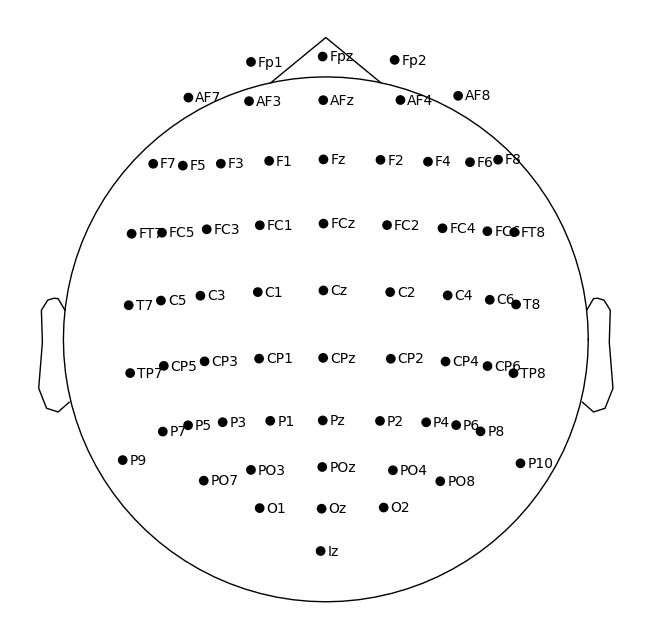

<Figure size 640x480 with 0 Axes>

In [45]:
# Visualize electrode layout
fig = raw.plot_sensors(show_names=True, kind='topomap')
fig.suptitle(f'{SUBJECT_ID} — Electrode positions (standard_1020)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 1.4 — Visual Inspection of the Raw Data

Plot the raw continuous data and scroll through it to assess recording quality.

**What to look for:**
1. **Flat channels** — zero or near-zero amplitude (likely disconnected electrodes)
2. **Excessively noisy channels** — dramatically higher amplitude or high-frequency noise vs. neighbors
3. **Large slow drifts** — very slow oscillations (< 0.1 Hz) from movement or poor electrode impedance
4. **Muscle artifacts** — high-frequency bursts (> 20 Hz) from jaw clenching, swallowing, or movement
5. **Eye blinks and saccades** — large, slow deflections at frontal electrodes (Fp1, Fp2)
6. **Electrical line noise** — sustained **50 Hz** hum (Netherlands mains frequency)
7. **Event markers** — triggers appear at expected times and in the expected pattern

In [ ]:
# Interactive scrollable plot
# Switch to Qt backend so you can scroll through the recording.
%matplotlib qt

raw.plot(
    duration=20,
    n_channels=30,
    scalings='auto',
    title=f'{SUBJECT_ID} — Raw EEG (scroll to inspect)',
    block=True,    # pauses execution until the window is closed
)

%matplotlib inline

# Print bad channels marked during inspection
if raw.info['bads']:
    print(f'Bad channels marked ({len(raw.info["bads"])}): {raw.info["bads"]}')
else:
    print('No bad channels marked.')

#! NOTE 12/03/2026 -> try to make this plot only for the electrodes covering V1/V2 (e.g. O1, O2, Oz, POz, Pz) ,
#! since those are the ones expected to show the strongest RIFT response.

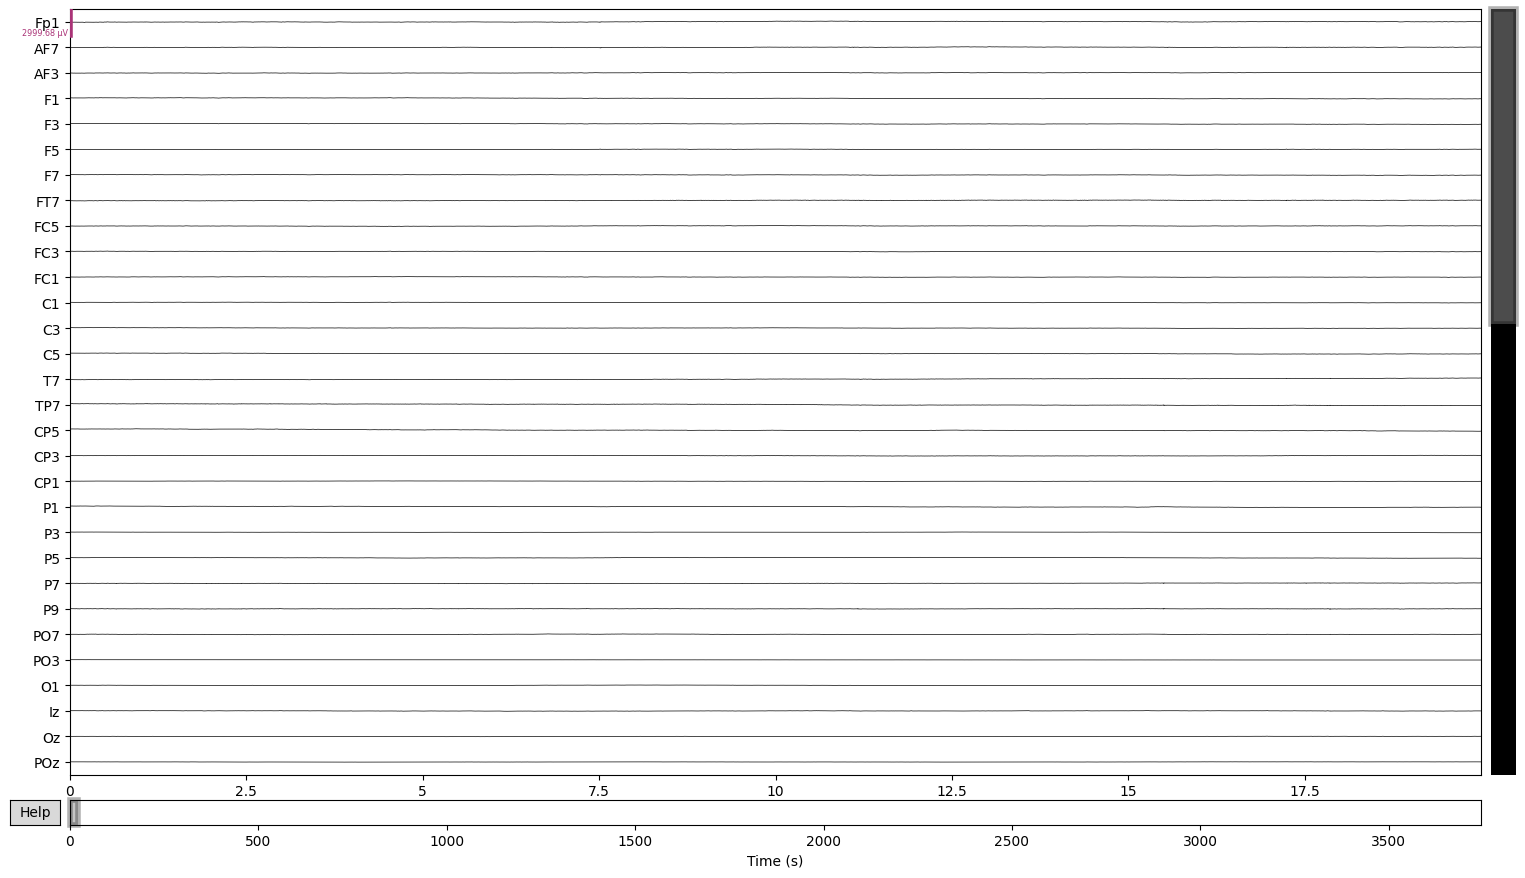

In [46]:
# Static snapshot — first 20 seconds (for inline / non-interactive environments)
fig = raw.plot(
    duration=20,
    n_channels=30,
    scalings='auto',
    title=f'{SUBJECT_ID} — Raw EEG (first 20 s)',
    show=False,
)
plt.tight_layout()
plt.show()

In [ ]:
# Record your findings from the visual inspection.
# Update these after scrolling through the data.

inspection_notes = {
    'flat_channels'   : [],    # e.g. ['Cz', 'T8']
    'noisy_channels'  : [],    # e.g. ['FT9']
    'slow_drifts'     : False,
    'muscle_artifacts': False,
    'eye_blinks'      : False,
    'line_noise_50hz' : False,
    'other_notes'     : '',
}

print('Visual inspection notes:')
for k, v in inspection_notes.items():
    print(f'  {k:20s}: {v}')

---
## 1.5 — Check Power Spectral Density (PSD)

Plot the PSD of the raw data to identify frequency-domain problems **before** preprocessing.

**What to look for:**
1. A clear **60 Hz peak** (RIFT signal) and possibly harmonics at 120 Hz and 180 Hz
2. Whether the 60 Hz response is consistent across channels — weak/absent channels may indicate quality issues
3. Any excessive **50 Hz line noise** (Netherlands mains frequency)
4. Reasonable overall spectral shape — typical **alpha bump** around 8–13 Hz
5. Whether individual channels have widely different spectra (bad channel indicator)

> **Note:** Analyse during periods when the RIFT flicker is **ON** to ensure the 60 Hz SSVEP response is captured.

c:\Users\dalam\miniconda3\envs\RIFT\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


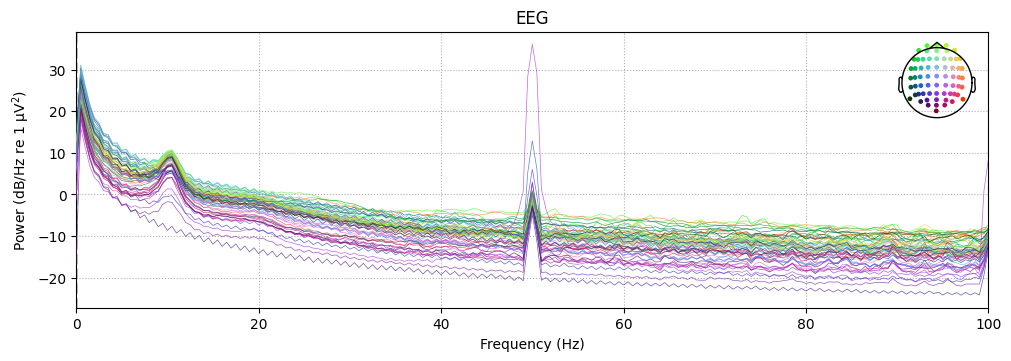

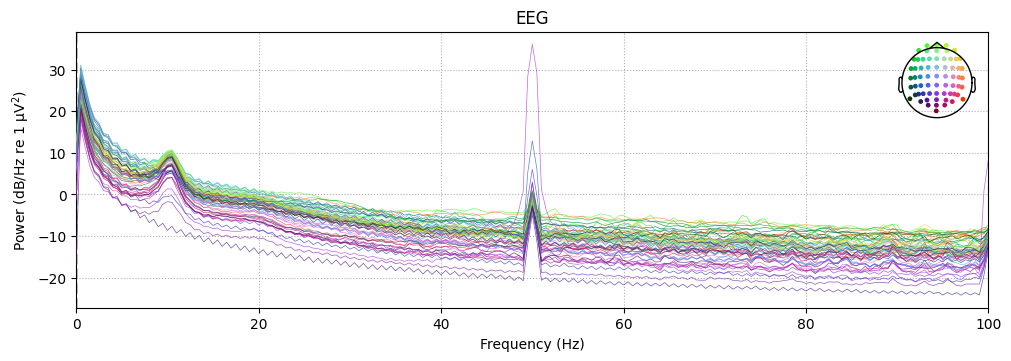

In [47]:
# Full PSD up to 100 Hz — all EEG channels
raw.compute_psd(fmax=100).plot()

C:\Users\dalam\AppData\Local\Temp\ipykernel_22744\1823467840.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


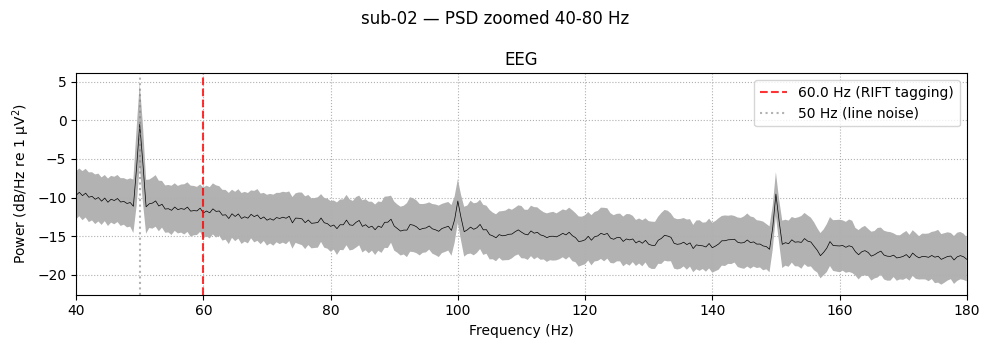

In [ ]:
# PSD zoomed around the tagging frequency (40–80 Hz) — channel average
psd_zoom = raw.compute_psd(fmin=40, fmax=80, picks='eeg')     #! fmin=40 - fmax=80 by default
fig = psd_zoom.plot(average=True, show=False)
ax  = fig.axes[0]
ax.axvline(TAGGING_FREQ, color='red',  linestyle='--', alpha=0.8,
           label=f'{TAGGING_FREQ} Hz (RIFT tagging)')
ax.axvline(50.0,         color='gray', linestyle=':',  alpha=0.6,
           label='50 Hz (line noise)')
ax.legend()
fig.suptitle(f'{SUBJECT_ID} — PSD zoomed 40-80 Hz', fontsize=12)
plt.tight_layout()
plt.show()

In [49]:
# Quantify the 60 Hz peak: compute SNR per channel
# SNR = power at tagging freq / mean power of neighboring bins (±2-5 Hz away)

psd_full = raw.compute_psd(fmin=30, fmax=100, picks='eeg')
freqs    = psd_full.freqs
power    = psd_full.get_data()   # shape: (n_channels, n_freqs)

foi_idx = np.argmin(np.abs(freqs - TAGGING_FREQ))

neighbor_mask = (
    ((freqs >= TAGGING_FREQ - 5) & (freqs <= TAGGING_FREQ - 2)) |
    ((freqs >= TAGGING_FREQ + 2) & (freqs <= TAGGING_FREQ + 5))
)

signal_power = power[:, foi_idx]
noise_power  = power[:, neighbor_mask].mean(axis=1)
snr_db       = 10 * np.log10(signal_power / noise_power)
ch_names     = psd_full.ch_names

top_idx = np.argsort(snr_db)[::-1][:10]
print(f'Top 10 channels by {TAGGING_FREQ} Hz SNR (raw, unpreprocessed):')
print(f'{"Channel":>10}  {"SNR (dB)":>10}')
print('-' * 24)
for idx in top_idx:
    print(f'{ch_names[idx]:>10}  {snr_db[idx]:>10.2f}')

Top 10 channels by 60.0 Hz SNR (raw, unpreprocessed):
   Channel    SNR (dB)
------------------------
        C3        1.07
       FC3        1.04
        F3        0.94
        F8        0.91
       FC1        0.77
        T7        0.58
        C1        0.57
        Oz        0.52
       AF7        0.45
       Fp1        0.45


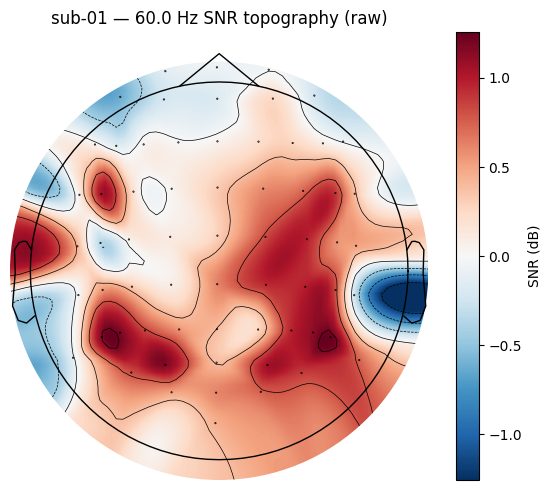

In [35]:
# Topographic map of 60 Hz SNR
# Expected: highest SNR over occipital/parietal channels (Oz, O1, O2, POz, PO3, PO4)

fig, ax = plt.subplots(figsize=(6, 5))
im, _   = mne.viz.plot_topomap(
    snr_db,
    psd_full.info,  # raw.info contains all 73 channels
    axes=ax,
    show=False,
    cmap='RdBu_r',
)
plt.colorbar(im, ax=ax, label='SNR (dB)')
ax.set_title(f'{SUBJECT_ID} — {TAGGING_FREQ} Hz SNR topography (raw)')
plt.tight_layout()
plt.show()

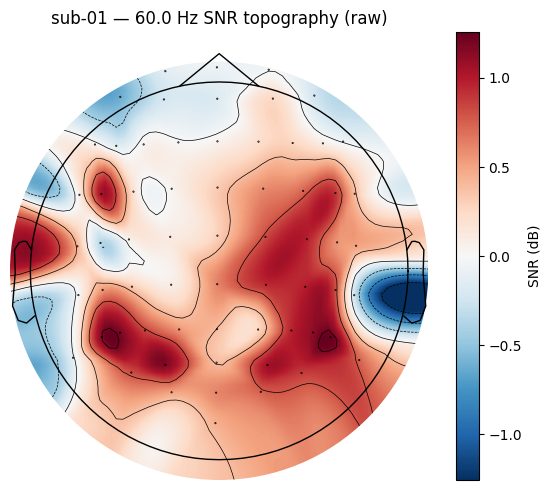

In [36]:
# Topographic map of 60 Hz SNR
# Expected: highest SNR over occipital/parietal channels (Oz, O1, O2, POz, PO3, PO4)

mastoid_mask = np.array([ch not in MASTOID_CHANNELS for ch in ch_names])
info_plot    = mne.pick_info(psd_full.info, np.where(mastoid_mask)[0])

fig, ax = plt.subplots(figsize=(6, 5))
im, _   = mne.viz.plot_topomap(
    snr_db[mastoid_mask],
    info_plot,
    axes=ax,
    show=False,
    cmap='RdBu_r',
)
plt.colorbar(im, ax=ax, label='SNR (dB)')
ax.set_title(f'{SUBJECT_ID} — {TAGGING_FREQ} Hz SNR topography (raw)')
plt.tight_layout()
plt.show()


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

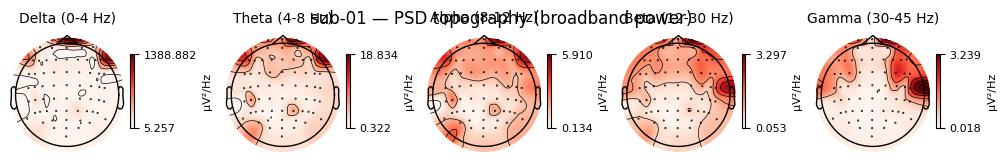

In [37]:
# PSD topography — broadband power per channel
# Channels that look very different from their neighbors may be bad.

fig = raw.compute_psd(fmax=100, picks='eeg').plot_topomap(show=False)
fig.suptitle(f'{SUBJECT_ID} — PSD topography (broadband power)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Phase 1 Summary

Run the cell below after completing all checks to get a concise summary before moving to **Phase 2 (Preprocessing)**.

In [ ]:
print('=' * 60)
print(f'PHASE 1 SUMMARY -- {SUBJECT_ID}')
print('=' * 60)
print(f'File           : {RAW_FILE}')
print(f'Sampling rate  : {raw.info["sfreq"]} Hz')
print(f'Total channels : {raw.info["nchan"]}')
print(f'EEG channels   : {len(mne.pick_types(raw.info, eeg=True))}')
print(f'EOG channels   : {len(mne.pick_types(raw.info, eog=True))}')
print(f'Duration       : {raw.times[-1]:.1f} s  ({raw.times[-1] / 60:.1f} min)')
print(f'Annotations    : {len(raw.annotations)}')
print()
print('Potential bad channels (from visual inspection):')
print(f'  Flat    : {inspection_notes["flat_channels"]}')
print(f'  Noisy   : {inspection_notes["noisy_channels"]}')
print()
print(f'Top 3 channels by {TAGGING_FREQ} Hz SNR (raw):')
for idx in top_idx[:3]:
    print(f'  {ch_names[idx]}: {snr_db[idx]:.2f} dB')
print()
print('Next step: Phase 2 -- Preprocessing')